# SWOT RiverSP reaches: exploration, time series, profiles, and mapping

This training notebook introduces several common workflows using **SWOT RiverSP Reach** products.

The exercises demonstrate how to:

1. Explore a river network interactively and identify a `reach_id`.
2. Build a Water Surface Elevation (WSE) time series for one reach.
3. Plot longitudinal WSE profiles for a selected river.
4. Combine multiple RiverSP Reach files and create a basin-scale WSE map.

All example paths are built from `Path.home()`, making the notebook easier to use on Windows, Linux, and macOS.

> **Training note:** Run the cells in order when variables or files created in a previous exercise are required.


## 1. Explore the SWORD river network and identify a reach

This first exercise displays the Vietnam river network on an interactive map.

Clicking a river reach opens a popup showing:

- `reach_id`: the unique SWORD identifier of the river reach;
- `river_name`: the river name stored in the database.

The `reach_id` can then be copied and used in the next exercise to extract a SWOT WSE time series.


In [15]:
from pathlib import Path

from ipyleaflet import Map, GeoJSON, Popup
import geopandas as gpd
from shapely.geometry import shape
from ipywidgets import HTML
from IPython.display import display


# ============================================================
# USER CONFIGURATION
# ============================================================

# General directory used by the training course.
COURSE_DIR = Path.home() / "course/swot_data"

# SWORD river network for Vietnam.
SWORD_FILE = Path.home() / "course/data/sword_vietnam.gpkg"


# ============================================================
# LOAD THE RIVER NETWORK
# ============================================================

popup_layer = None

try:
    # Read the SWORD vector file.
    gdf = gpd.read_file(SWORD_FILE)

    # Interactive web maps use geographic coordinates (longitude/latitude).
    gdf = gdf.to_crs(epsg=4326)

    print(f"File loaded successfully: {len(gdf)} reaches found.")
    print("Available columns:")
    print(list(gdf.columns))

    # Use the dataset extent to automatically center the map.
    minx, miny, maxx, maxy = gdf.total_bounds

    center_lat = (miny + maxy) / 2
    center_lon = (minx + maxx) / 2


    # ========================================================
    # CREATE THE INTERACTIVE MAP
    # ========================================================

    m = Map(
        center=(center_lat, center_lon),
        zoom=6,
        layout={
            "height": "600px",
            "width": "1000px"
        },
        scroll_wheel_zoom=True
    )

    # Convert the GeoDataFrame to GeoJSON for ipyleaflet.
    geojson_data = gdf.__geo_interface__

    geojson_layer = GeoJSON(
        data=geojson_data,
        style={
            "color": "green",
            "opacity": 0.8,
            "weight": 2,
            "fillOpacity": 0.15,
        },
        hover_style={
            "color": "red",
            "weight": 4,
            "fillOpacity": 0.25,
        }
    )


    # ========================================================
    # POPUP FUNCTION
    # ========================================================

    def on_click(
        event=None,
        feature=None,
        id=None,
        properties=None,
        **kwargs
    ):
        """
        Display the reach ID and river name when a river reach is clicked.
        """
        global popup_layer

        try:
            # Depending on the ipyleaflet version, properties may be
            # passed directly or stored inside the GeoJSON feature.
            if properties is None and feature is not None:
                properties = feature.get("properties", {})

            if feature is None:
                print("No feature was received from the map click.")
                return

            reach_id = properties.get("reach_id", "N/A")
            river_name = properties.get("river_name", "N/A")

            # Place the popup at a representative point of the selected reach.
            geom = shape(feature["geometry"])
            point = geom.representative_point()

            lon = point.x
            lat = point.y

            html_content = HTML(
                f"""
                <div style="font-size: 14px; min-width: 180px;">
                    <b>Reach ID:</b> {reach_id}<br>
                    <b>River Name:</b> {river_name}
                </div>
                """
            )

            # Remove the previous popup so that only one popup remains visible.
            if popup_layer is not None:
                try:
                    m.remove_layer(popup_layer)
                except Exception:
                    pass

            popup_layer = Popup(
                location=(lat, lon),
                child=html_content,
                close_button=True,
                auto_close=True,
                close_on_escape_key=True
            )

            m.add_layer(popup_layer)

        except Exception as e:
            print(f"Popup error: {e}")


    # Connect map clicks to the popup function.
    geojson_layer.on_click(on_click)

    # Add the river network to the map.
    m.add_layer(geojson_layer)

    display(m)

except Exception as e:
    print(f"Error loading or displaying the SWORD file: {e}")


File loaded successfully: 1761 reaches found.
Available columns:
['x', 'y', 'reach_id', 'reach_len', 'n_nodes', 'wse', 'wse_var', 'width', 'width_var', 'facc', 'n_chan_max', 'n_chan_mod', 'obstr_type', 'grod_id', 'hfalls_id', 'slope', 'dist_out', 'lakeflag', 'max_width', 'n_rch_up', 'n_rch_dn', 'rch_id_up', 'rch_id_dn', 'swot_orbit', 'swot_obs', 'type', 'river_name', 'edit_flag', 'trib_flag', 'path_freq', 'path_order', 'path_segs', 'main_side', 'strm_order', 'end_reach', 'network', 'layer', 'path', 'geometry']


Map(center=[np.float64(15.939984750179713), np.float64(105.78065206312951)], controls=(ZoomControl(options=['p…

## 2. Build a WSE time series for one SWOT reach

This exercise scans the downloaded **RiverSP Reach ZIP files** and extracts WSE observations for one selected `reach_id`.

Only observations satisfying the selected `reach_q` quality classes are retained.

In this example:

```python
VALID_REACH_Q = [0, 1]
```

keeps nominal and suspect-quality reaches while excluding degraded and bad-quality observations.

The resulting observations are:

- sorted chronologically;
- saved to a CSV file;
- displayed as a WSE time series.


RiverSP Reach ZIP files found: 956
Reading mode: FAST (/vsizip/ + pyogrio)

Searching 956 RiverSP files for reach 43682500041...
Found: 26/956 | SWOT_L2_HR_RiverSP_Reach_027_090_AS_20250116T213630_20250116T214746_PGD0_01.zip
Found: 56/956 | SWOT_L2_HR_RiverSP_Reach_028_090_AS_20250206T182133_20250206T183249_PGD0_01.zip
Found: 83/956 | SWOT_L2_HR_RiverSP_Reach_029_090_AS_20250227T150639_20250227T151755_PGD0_01.zip
Found: 108/956 | SWOT_L2_HR_RiverSP_Reach_030_090_AS_20250320T115144_20250320T120300_PGD0_01.zip
Found: 133/956 | SWOT_L2_HR_RiverSP_Reach_031_021_AS_20250407T214120_20250407T215641_PGD0_01.zip
Found: 138/956 | SWOT_L2_HR_RiverSP_Reach_031_090_AS_20250410T083648_20250410T084804_PGD0_01.zip
Found: 160/956 | SWOT_L2_HR_RiverSP_Reach_032_021_AS_20250428T182626_20250428T184147_PGD0_01.zip
Found: 165/956 | SWOT_L2_HR_RiverSP_Reach_032_090_AS_20250501T052153_20250501T053309_PGD0_01.zip
Found: 216/956 | SWOT_L2_HR_RiverSP_Reach_033_021_AS_20250519T151130_20250519T152651_PID0_01.zip
F

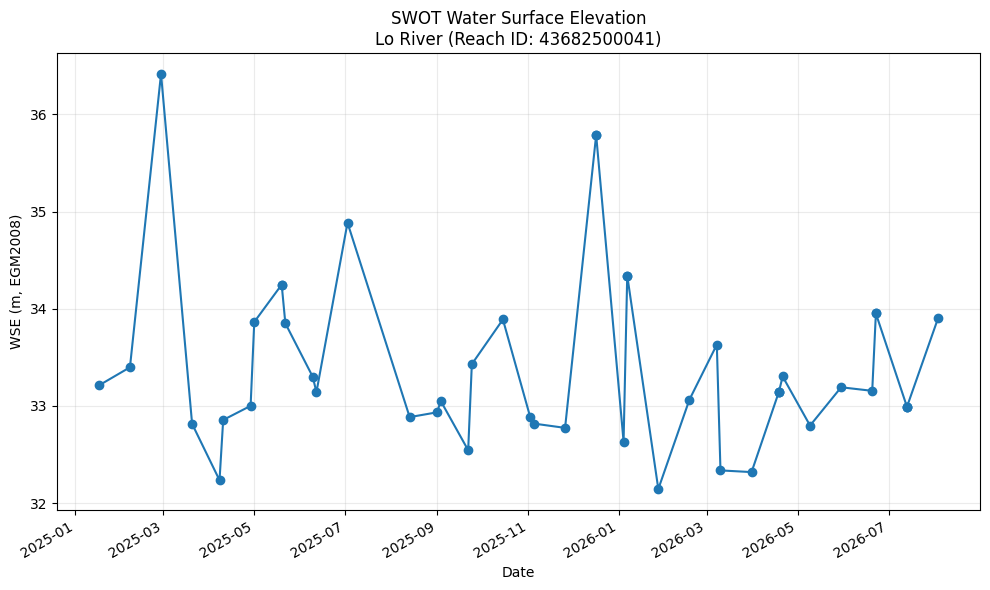

In [16]:
from pathlib import Path
import tempfile
import zipfile

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. USER CONFIGURATION
# ============================================================

# General directory used by the SWOT training course.
COURSE_DIR = Path.home() / "course/swot_data"


# Directory containing the downloaded RiverSP Reach ZIP files.
#
# Windows:
# C:\Users\username\swot_course\vietnam_river
#
# Linux:
# /home/username/swot_course/vietnam_river
#
# macOS:
# /Users/username/swot_course/vietnam_river
ZIP_DIR = (
    COURSE_DIR
    / "vietnam_river"
)


# Directory used for output files.
OUTPUT_DIR = Path.home() / "outputs_swot_course"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Reach selected from the interactive SWORD map.
TARGET_REACH_ID = "43682500041"


# SWOT RiverSP reach quality classes to retain.
#
# 0 = good
# 1 = suspect
VALID_REACH_Q = [
    0,
    1,
]


# ============================================================
# 2. COLUMNS REQUIRED FOR THE TIME SERIES
# ============================================================

# Only the attributes required for this exercise are read.
#
# Geometry is intentionally excluded because it is not needed
# to construct a WSE time series.
READ_COLUMNS = [
    "reach_id",
    "reach_q",
    "wse",
    "time_str",
    "river_name",
]


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def choose_reach_shapefile(zip_path):
    """
    Identify the RiverSP Reach shapefile inside a ZIP archive.

    RiverSP ZIP archives may contain several files belonging to
    the same shapefile family (.shp, .dbf, .shx, .prj, etc.).

    This function searches only for .shp files and prefers one
    whose filename contains 'Reach'.
    """

    try:

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            shp_members = [
                member
                for member in z.namelist()
                if member.lower().endswith(".shp")
            ]


    except zipfile.BadZipFile:

        print(
            f"[WARNING] Invalid ZIP file: {zip_path.name}"
        )

        return None


    if not shp_members:
        return None


    reach_files = [
        member
        for member in shp_members
        if "reach" in Path(member).name.lower()
    ]


    if reach_files:
        return reach_files[0]


    return shp_members[0]


def build_vsizip_path(
    zip_path,
    shp_member
):
    """
    Build a GDAL /vsizip/ path.

    GDAL can use this virtual path to read a shapefile directly
    from inside a ZIP archive without extracting the files first.
    """

    zip_absolute = (
        zip_path
        .resolve()
        .as_posix()
    )


    return (
        f"/vsizip/{zip_absolute}/{shp_member}"
    )


def get_first_river_name(df):
    """
    Return the first valid river name found in the selected data.
    """

    if "river_name" not in df.columns:
        return None


    values = (
        df["river_name"]
        .dropna()
        .astype(str)
        .str.strip()
    )


    values = values[
        ~values.str.lower().isin(
            [
                "",
                "nan",
                "none",
                "n/a",
            ]
        )
    ]


    if not values.empty:
        return values.iloc[0]


    return None


# ============================================================
# 4. FAST READER
# ============================================================

def read_target_reach_fast(
    zip_path,
    target_reach_id
):
    """
    Read only the selected reach directly from a RiverSP ZIP file.

    This is the preferred and fastest method.

    The function:
    - does not extract the ZIP archive;
    - does not load river geometries;
    - reads only the required columns;
    - filters reach_id while GDAL reads the shapefile.

    Returns
    -------
    pandas.DataFrame or None
        The selected reach observation or None if the reach is
        not present in the RiverSP file.
    """

    shp_member = choose_reach_shapefile(
        zip_path
    )


    if shp_member is None:
        return None


    vsi_path = build_vsizip_path(
        zip_path,
        shp_member
    )


    # --------------------------------------------------------
    # FIRST ATTEMPT: reach_id stored as text
    # --------------------------------------------------------

    where_text = (
        f"reach_id = '{target_reach_id}'"
    )


    try:

        df = gpd.read_file(
            vsi_path,

            # pyogrio provides fast GDAL-based vector reading.
            engine="pyogrio",

            # Read only the attributes required for the exercise.
            columns=READ_COLUMNS,

            # Apply the reach filter while reading the file.
            where=where_text,

            # Geometry is not needed for the time series.
            ignore_geometry=True,
        )


        if not df.empty:
            return df


    except Exception:
        pass


    # --------------------------------------------------------
    # SECOND ATTEMPT: reach_id stored as a numeric field
    # --------------------------------------------------------

    if str(target_reach_id).isdigit():

        try:

            where_numeric = (
                f"reach_id = {int(target_reach_id)}"
            )


            df = gpd.read_file(
                vsi_path,
                engine="pyogrio",
                columns=READ_COLUMNS,
                where=where_numeric,
                ignore_geometry=True,
            )


            if not df.empty:
                return df


        except Exception:
            pass


    # The selected reach was not found in this acquisition.
    return None


# ============================================================
# 5. FALLBACK READER
# ============================================================

def read_target_reach_fallback(
    zip_path,
    target_reach_id
):
    """
    Traditional RiverSP reader.

    This method is used only if the local installation cannot
    read shapefiles directly through GDAL /vsizip/.

    It extracts the ZIP into a temporary folder, reads the
    shapefile normally, and filters the selected reach afterwards.
    """

    shp_member = choose_reach_shapefile(
        zip_path
    )


    if shp_member is None:
        return None


    with tempfile.TemporaryDirectory(
        prefix="swot_reach_"
    ) as tmp_dir:


        try:

            with zipfile.ZipFile(
                zip_path,
                "r"
            ) as z:

                z.extractall(
                    tmp_dir
                )


            shapefile_path = (
                Path(tmp_dir)
                / shp_member
            )


            gdf = gpd.read_file(
                shapefile_path
            )


        except Exception:

            return None


        if gdf.empty:
            return None


        if "reach_id" not in gdf.columns:
            return None


        reach_mask = (
            gdf["reach_id"]
            .astype(str)
            .str.strip()
            .eq(str(target_reach_id))
        )


        filtered = gdf[
            reach_mask
        ].copy()


        if filtered.empty:
            return None


        # Keep only the columns needed by this exercise.
        available_columns = [
            column
            for column in READ_COLUMNS
            if column in filtered.columns
        ]


        return filtered[
            available_columns
        ].copy()


# ============================================================
# 6. TEST FAST READER SUPPORT
# ============================================================

def test_fast_reader(zip_files):
    """
    Test whether the installed GeoPandas/GDAL environment
    can read RiverSP shapefiles directly from ZIP archives.

    Only the first valid ZIP file is tested.
    """

    if not zip_files:
        return False


    for test_zip in zip_files[:10]:


        shp_member = choose_reach_shapefile(
            test_zip
        )


        if shp_member is None:
            continue


        vsi_path = build_vsizip_path(
            test_zip,
            shp_member
        )


        try:

            # Read only one row and do not load geometry.
            gpd.read_file(
                vsi_path,
                engine="pyogrio",
                rows=1,
                ignore_geometry=True,
            )


            return True


        except Exception:
            continue


    return False


# ============================================================
# 7. FIND RIVERSP REACH ZIP FILES
# ============================================================

zip_files = sorted(
    p
    for p in ZIP_DIR.glob("*.zip")
    if "Reach" in p.name
)


if not zip_files:

    raise FileNotFoundError(
        f"No RiverSP Reach ZIP files were found in:\n"
        f"{ZIP_DIR}"
    )


print(
    f"RiverSP Reach ZIP files found: {len(zip_files):,}"
)


# ============================================================
# 8. DETERMINE THE READING METHOD
# ============================================================

FAST_READER_AVAILABLE = test_fast_reader(
    zip_files
)


if FAST_READER_AVAILABLE:

    print(
        "Reading mode: FAST (/vsizip/ + pyogrio)"
    )


else:

    print(
        "Reading mode: FALLBACK (temporary extraction)"
    )


# ============================================================
# 9. STORAGE
# ============================================================

# One dictionary will be stored for each valid SWOT observation.
#
# This approach is safer and easier to understand than keeping
# separate parallel lists for date, WSE, reach quality, etc.
records = []


target_river_name = None


# Counters used for the final summary.
n_files_scanned = 0
n_files_with_reach = 0
n_valid_observations = 0


# ============================================================
# 10. PROCESS ALL RIVERSP FILES
# ============================================================

print()

print(
    f"Searching {len(zip_files):,} RiverSP files "
    f"for reach {TARGET_REACH_ID}..."
)


for i, zip_path in enumerate(
    zip_files,
    start=1
):


    n_files_scanned += 1


    # --------------------------------------------------------
    # READ ONLY THE TARGET REACH
    # --------------------------------------------------------

    if FAST_READER_AVAILABLE:

        filtered_df = read_target_reach_fast(
            zip_path,
            TARGET_REACH_ID
        )


    else:

        filtered_df = read_target_reach_fallback(
            zip_path,
            TARGET_REACH_ID
        )


    # The selected reach is not present in this acquisition.
    if (
        filtered_df is None
        or filtered_df.empty
    ):

        continue


    n_files_with_reach += 1


    # --------------------------------------------------------
    # CHECK REQUIRED ATTRIBUTES
    # --------------------------------------------------------

    required_columns = {
        "reach_q",
        "wse",
        "time_str",
    }


    missing_columns = (
        required_columns
        - set(filtered_df.columns)
    )


    if missing_columns:

        print(
            f"[WARNING] {zip_path.name}: "
            f"missing columns {sorted(missing_columns)}"
        )

        continue


    # --------------------------------------------------------
    # GET THE RIVER NAME
    # --------------------------------------------------------

    if target_river_name is None:

        target_river_name = get_first_river_name(
            filtered_df
        )


    # --------------------------------------------------------
    # CONVERT REACH QUALITY
    # --------------------------------------------------------

    filtered_df["reach_q"] = pd.to_numeric(
        filtered_df["reach_q"],
        errors="coerce"
    )


    # --------------------------------------------------------
    # FILTER REACH QUALITY
    # --------------------------------------------------------

    filtered_df = filtered_df[
        filtered_df["reach_q"]
        .isin(VALID_REACH_Q)
    ].copy()


    if filtered_df.empty:
        continue


    # --------------------------------------------------------
    # CONVERT WSE
    # --------------------------------------------------------

    filtered_df["wse"] = pd.to_numeric(
        filtered_df["wse"],
        errors="coerce"
    )


    # --------------------------------------------------------
    # CONVERT SWOT TIME
    # --------------------------------------------------------

    filtered_df["Date"] = pd.to_datetime(
        filtered_df["time_str"],
        errors="coerce",
        utc=True
    )


    # Keep observations with both a valid time and WSE.
    filtered_df = filtered_df.dropna(
        subset=[
            "Date",
            "wse",
        ]
    )


    if filtered_df.empty:
        continue


    # --------------------------------------------------------
    # STORE OBSERVATIONS
    # --------------------------------------------------------

    for _, row in filtered_df.iterrows():


        records.append({

            "Reach_ID":
                TARGET_REACH_ID,

            "River_Name":
                target_river_name,

            "Date":
                row["Date"],

            "WSE_m_EGM08":
                row["wse"],

            "reach_q":
                row["reach_q"],

            "source_zip":
                zip_path.name,

        })


        n_valid_observations += 1


    # Print only when the requested reach is actually found.
    print(
        f"Found: {i:,}/{len(zip_files):,} | "
        f"{zip_path.name}"
    )


# ============================================================
# 11. CREATE THE FINAL TIME SERIES
# ============================================================

if not records:


    print()

    print(
        f"No valid observations were found for "
        f"Reach ID {TARGET_REACH_ID}."
    )


else:


    df = pd.DataFrame(
        records
    )


    # Sort observations chronologically.
    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )


    # ========================================================
    # 12. CREATE A LABEL FOR THE REACH
    # ========================================================

    if target_river_name:

        reach_label = (
            f"{target_river_name} "
            f"(Reach ID: {TARGET_REACH_ID})"
        )


    else:

        target_river_name = "Unknown river"

        df["River_Name"] = (
            target_river_name
        )


        reach_label = (
            f"Reach ID: {TARGET_REACH_ID}"
        )


    # ========================================================
    # 13. SAVE THE CSV
    # ========================================================

    output_csv = (
        OUTPUT_DIR
        / (
            f"{TARGET_REACH_ID}_"
            "riversp_wse_data.csv"
        )
    )


    df.to_csv(
        output_csv,
        index=False
    )


    # ========================================================
    # 14. SUMMARY
    # ========================================================

    print()

    print(
        "============================================================"
    )

    print(
        "RiverSP search finished"
    )

    print(
        "============================================================"
    )

    print(
        f"River: {reach_label}"
    )

    print(
        f"ZIP files scanned: {n_files_scanned:,}"
    )

    print(
        f"ZIP files containing the reach: "
        f"{n_files_with_reach:,}"
    )

    print(
        f"Valid observations: {len(df):,}"
    )

    print(
        "First observation: "
        f"{df['Date'].min().strftime('%Y-%m-%d')}"
    )

    print(
        "Last observation: "
        f"{df['Date'].max().strftime('%Y-%m-%d')}"
    )

    print(
        f"CSV saved to: {output_csv}"
    )


    # ========================================================
    # 15. PLOT THE WSE TIME SERIES
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    ax.plot(
        df["Date"],
        df["WSE_m_EGM08"],
        marker="o",
        linestyle="-"
    )


    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "WSE (m, EGM2008)"
    )


    # Show the river name and reach ID together.
    ax.set_title(
        "SWOT Water Surface Elevation\n"
        f"{reach_label}"
    )


    ax.grid(
        True,
        alpha=0.25
    )


    fig.autofmt_xdate()

    fig.tight_layout()

    plt.show()


## 3. Plot longitudinal WSE profiles for a selected river

This exercise extracts all valid reaches belonging to one river and plots WSE as a function of `p_dist_out`.

`p_dist_out` is converted from meters to kilometers for easier interpretation.

Because many SWOT acquisitions may be available, assigning a different color and legend entry to every profile quickly makes the figure difficult to read. For the training version:

- all profiles use the same neutral visual style;
- no per-file legend is created;
- the figure reports only the **first and last profile dates**.

This keeps the figure readable even when many SWOT acquisitions are available.


PyArrow acceleration: False
RiverSP Reach ZIP files found: 956
Reading mode: FAST (/vsizip/ + pyogrio)

Searching 956 RiverSP files for 'Black River'...
Found: 5/956 | SWOT_L2_HR_RiverSP_Reach_026_299_AS_20250103T121805_20250103T123406_PGD0_01.zip
Found: 7/956 | SWOT_L2_HR_RiverSP_Reach_026_327_AS_20250104T121926_20250104T123357_PGD0_01.zip
Found: 9/956 | SWOT_L2_HR_RiverSP_Reach_026_355_AS_20250105T122107_20250105T123328_PGD0_01.zip
Found: 10/956 | SWOT_L2_HR_RiverSP_Reach_026_368_AS_20250105T231332_20250105T232431_PGD0_01.zip
Found: 12/956 | SWOT_L2_HR_RiverSP_Reach_026_396_AS_20250106T231413_20250106T232533_PGD0_01.zip
Found: 14/956 | SWOT_L2_HR_RiverSP_Reach_026_424_AS_20250107T231524_20250107T232811_PGD0_01.zip
Found: 21/956 | SWOT_L2_HR_RiverSP_Reach_027_021_AS_20250114T104102_20250114T105623_PGD0_01.zip
Found: 23/956 | SWOT_L2_HR_RiverSP_Reach_027_049_AS_20250115T104302_20250115T105624_PGD0_01.zip
Found: 25/956 | SWOT_L2_HR_RiverSP_Reach_027_077_AS_20250116T104531_20250116T10555

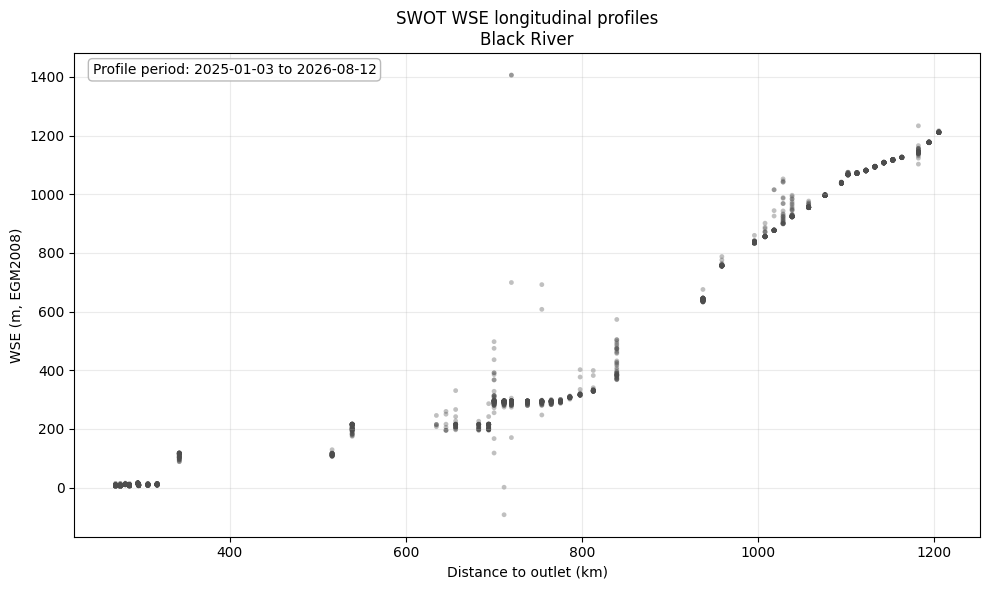

Profile period: 2025-01-03 to 2026-08-12


In [13]:
from pathlib import Path
import re
import zipfile

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. USER CONFIGURATION
# ============================================================

# General directory used by the SWOT training course.
COURSE_DIR = Path.home() / "course/swot_data"


# Directory containing RiverSP Reach ZIP files.
ZIP_DIR = (
    COURSE_DIR
    / "vietnam_river"
)


# River to analyze.
TARGET_RIVER_NAME = "Black River"


# SWOT RiverSP reach quality classes to retain.
#
# 0 = good
# 1 = suspect
VALID_REACH_Q = [
    0,
    1,
]


# Directory used for output files.
OUTPUT_DIR = Path.home() / "outputs_swot_course"


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Output table containing all longitudinal-profile observations.
OUTPUT_CSV = (
    OUTPUT_DIR
    / (
        f"profile_wse_"
        f"{TARGET_RIVER_NAME.replace(' ', '_')}.csv"
    )
)


# ============================================================
# 2. COLUMNS REQUIRED FOR THE PROFILE
# ============================================================

# Only these attributes are needed for the longitudinal profile.
#
# Geometry is intentionally excluded because p_dist_out already
# provides the along-river position required for the plot.
READ_COLUMNS = [
    "river_name",
    "reach_q",
    "p_dist_out",
    "wse",
    "time_str",
]


# ============================================================
# 3. OPTIONAL ARROW ACCELERATION
# ============================================================

# GeoPandas/pyogrio can use PyArrow for faster data transfer
# when PyArrow is installed.
try:

    import pyarrow

    USE_ARROW = True

except ImportError:

    USE_ARROW = False


print(
    f"PyArrow acceleration: {USE_ARROW}"
)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def get_cycle_and_pass(filename):
    """
    Extract SWOT cycle and pass numbers from a standard
    RiverSP Reach filename.

    Expected pattern
    ----------------
    ...Reach_CCC_PPP_...

    where:

    CCC = SWOT cycle number
    PPP = SWOT pass number
    """

    match = re.search(
        r"Reach_(\d{3})_(\d{3})_",
        filename
    )


    if match:

        return (
            match.group(1),
            match.group(2)
        )


    return None, None


def choose_reach_shapefile(zip_path):
    """
    Identify the RiverSP Reach shapefile inside a ZIP archive.

    The function searches for .shp files and prefers a filename
    containing 'Reach'.
    """

    try:

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            shp_members = [
                member
                for member in z.namelist()
                if member.lower().endswith(".shp")
            ]


    except zipfile.BadZipFile:

        print(
            f"[WARNING] Invalid ZIP file: {zip_path.name}"
        )

        return None


    if not shp_members:

        return None


    reach_files = [
        member
        for member in shp_members
        if "reach" in Path(member).name.lower()
    ]


    if reach_files:

        return reach_files[0]


    return shp_members[0]


def build_vsizip_path(
    zip_path,
    shp_member
):
    """
    Build a GDAL /vsizip/ path.

    /vsizip/ allows GDAL to read files directly from a ZIP
    archive without extracting them to disk.
    """

    zip_absolute = (
        zip_path
        .resolve()
        .as_posix()
    )


    return (
        f"/vsizip/{zip_absolute}/{shp_member}"
    )


def get_profile_date(
    filtered_df,
    filename
):
    """
    Determine the acquisition date of one SWOT profile.

    The RiverSP time_str field is used whenever possible.

    If time_str is unavailable or invalid, the function searches
    for an YYYYMMDD date in the ZIP filename.
    """

    if "time_str" in filtered_df.columns:

        times = pd.to_datetime(
            filtered_df["time_str"],
            errors="coerce",
            utc=True
        ).dropna()


        if not times.empty:

            return times.min()


    # --------------------------------------------------------
    # FALLBACK: DATE FROM FILENAME
    # --------------------------------------------------------

    date_match = re.search(
        r"(20\d{6})",
        filename
    )


    if date_match:

        return pd.to_datetime(
            date_match.group(1),
            format="%Y%m%d",
            errors="coerce",
            utc=True
        )


    return pd.NaT


# ============================================================
# 5. FAST READER
# ============================================================

def read_target_river_fast(
    zip_path,
    river_name
):
    """
    Read only reaches belonging to the selected river.

    This is the fast method used by the notebook.

    It avoids:

    - extracting ZIP files;
    - loading river geometries;
    - loading unrelated attributes;
    - loading reaches belonging to other rivers.

    The SQL WHERE filter is applied by GDAL while the shapefile
    is being read.
    """

    shp_member = choose_reach_shapefile(
        zip_path
    )


    if shp_member is None:

        return None


    vsi_path = build_vsizip_path(
        zip_path,
        shp_member
    )


    # Escape apostrophes so that names such as
    # "O'Brien River" remain valid SQL strings.
    safe_river_name = (
        river_name
        .replace(
            "'",
            "''"
        )
    )


    where_clause = (
        f"river_name = '{safe_river_name}'"
    )


    try:

        df = gpd.read_file(
            vsi_path,

            engine="pyogrio",

            # Load only attributes required for this exercise.
            columns=READ_COLUMNS,

            # Filter the selected river during file reading.
            where=where_clause,

            # Geometry is not needed for the longitudinal profile.
            ignore_geometry=True,

            # Use Arrow acceleration when available.
            use_arrow=USE_ARROW,
        )


        if not df.empty:

            return df


    except Exception:

        return None


    return None


# ============================================================
# 6. TEST FAST ZIP READING
# ============================================================

def test_fast_reader(zip_files):
    """
    Check whether the local GeoPandas/GDAL installation supports
    direct reading from RiverSP ZIP archives.

    Only a few files are tested.
    """

    for zip_path in zip_files[:10]:


        shp_member = choose_reach_shapefile(
            zip_path
        )


        if shp_member is None:

            continue


        vsi_path = build_vsizip_path(
            zip_path,
            shp_member
        )


        try:

            gpd.read_file(
                vsi_path,
                engine="pyogrio",
                rows=1,
                ignore_geometry=True,
                use_arrow=USE_ARROW,
            )


            return True


        except Exception:

            continue


    return False


# ============================================================
# 7. FIND RIVERSP REACH ZIP FILES
# ============================================================

zip_files = sorted(
    p
    for p in ZIP_DIR.glob("*.zip")
    if "Reach" in p.name
)


if not zip_files:

    raise FileNotFoundError(
        f"No RiverSP Reach ZIP files were found in:\n"
        f"{ZIP_DIR}"
    )


print(
    f"RiverSP Reach ZIP files found: {len(zip_files):,}"
)


# ============================================================
# 8. CHECK FAST READING SUPPORT
# ============================================================

FAST_READER_AVAILABLE = test_fast_reader(
    zip_files
)


if not FAST_READER_AVAILABLE:

    raise RuntimeError(
        "Direct /vsizip/ reading is not available in this "
        "GeoPandas/GDAL installation."
    )


print(
    "Reading mode: FAST (/vsizip/ + pyogrio)"
)


# ============================================================
# 9. STORAGE
# ============================================================

# Store one small DataFrame per SWOT acquisition.
#
# Concatenating DataFrames once at the end is faster than
# repeatedly appending individual rows with iterrows().
profile_frames = []


profile_dates = []


# Summary counters.
n_files_scanned = 0
n_files_with_river = 0


# ============================================================
# 10. SEARCH ALL SWOT ACQUISITIONS
# ============================================================

print()

print(
    f"Searching {len(zip_files):,} RiverSP files "
    f"for '{TARGET_RIVER_NAME}'..."
)


for i, zip_path in enumerate(
    zip_files,
    start=1
):


    n_files_scanned += 1


    # --------------------------------------------------------
    # READ ONLY THE SELECTED RIVER
    # --------------------------------------------------------

    filtered_df = read_target_river_fast(
        zip_path,
        TARGET_RIVER_NAME
    )


    if (
        filtered_df is None
        or filtered_df.empty
    ):

        continue


    n_files_with_river += 1


    # --------------------------------------------------------
    # CHECK REQUIRED ATTRIBUTES
    # --------------------------------------------------------

    required_columns = {
        "reach_q",
        "p_dist_out",
        "wse",
    }


    missing_columns = (
        required_columns
        - set(filtered_df.columns)
    )


    if missing_columns:

        print(
            f"[WARNING] {zip_path.name}: "
            f"missing columns {sorted(missing_columns)}"
        )

        continue


    # --------------------------------------------------------
    # CONVERT REACH QUALITY
    # --------------------------------------------------------

    filtered_df["reach_q"] = pd.to_numeric(
        filtered_df["reach_q"],
        errors="coerce"
    )


    # --------------------------------------------------------
    # FILTER QUALITY
    # --------------------------------------------------------

    filtered_df = filtered_df[
        filtered_df["reach_q"]
        .isin(VALID_REACH_Q)
    ].copy()


    if filtered_df.empty:

        continue


    # --------------------------------------------------------
    # CONVERT DISTANCE AND WSE
    # --------------------------------------------------------

    filtered_df["p_dist_out_km"] = (
        pd.to_numeric(
            filtered_df["p_dist_out"],
            errors="coerce"
        )
        / 1000.0
    )


    filtered_df["wse_numeric"] = pd.to_numeric(
        filtered_df["wse"],
        errors="coerce"
    )


    filtered_df = filtered_df.dropna(
        subset=[
            "p_dist_out_km",
            "wse_numeric",
        ]
    )


    if filtered_df.empty:

        continue


    # --------------------------------------------------------
    # PROFILE DATE
    # --------------------------------------------------------

    profile_date = get_profile_date(
        filtered_df,
        zip_path.name
    )


    if pd.notna(
        profile_date
    ):

        profile_dates.append(
            profile_date
        )


    # --------------------------------------------------------
    # CYCLE AND PASS
    # --------------------------------------------------------

    cycle_info, pass_info = get_cycle_and_pass(
        zip_path.name
    )


    # --------------------------------------------------------
    # PREPARE DATA FROM THIS ACQUISITION
    # --------------------------------------------------------

    profile_df = filtered_df[
        [
            "p_dist_out_km",
            "wse_numeric",
            "reach_q",
        ]
    ].copy()


    profile_df = profile_df.rename(
        columns={
            "wse_numeric": "wse"
        }
    )


    profile_df["profile_date"] = (
        profile_date
        if pd.notna(profile_date)
        else pd.NaT
    )


    profile_df["cycle"] = (
        cycle_info
    )


    profile_df["pass"] = (
        pass_info
    )


    profile_df["river_name"] = (
        TARGET_RIVER_NAME
    )


    profile_df["source_zip"] = (
        zip_path.name
    )


    profile_frames.append(
        profile_df
    )


    # Print only when the requested river is actually found.
    print(
        f"Found: {i:,}/{len(zip_files):,} | "
        f"{zip_path.name}"
    )


# ============================================================
# 11. COMBINE ALL PROFILE OBSERVATIONS
# ============================================================

if not profile_frames:


    print()

    print(
        f"No valid longitudinal profiles were found for "
        f"'{TARGET_RIVER_NAME}'."
    )


else:


    df_all = pd.concat(
        profile_frames,
        ignore_index=True
    )


    # Sort first by acquisition date and then by distance
    # along the river.
    df_all = df_all.sort_values(
        [
            "profile_date",
            "p_dist_out_km",
        ]
    ).reset_index(
        drop=True
    )


    # ========================================================
    # 12. SAVE PROFILE DATA
    # ========================================================

    df_all.to_csv(
        OUTPUT_CSV,
        index=False
    )


    # ========================================================
    # 13. SUMMARY
    # ========================================================

    print()

    print(
        "============================================================"
    )

    print(
        "Longitudinal profile search finished"
    )

    print(
        "============================================================"
    )

    print(
        f"River: {TARGET_RIVER_NAME}"
    )

    print(
        f"ZIP files scanned: {n_files_scanned:,}"
    )

    print(
        f"ZIP files containing the river: "
        f"{n_files_with_river:,}"
    )

    print(
        f"Profile observations: {len(df_all):,}"
    )

    print(
        f"Profile data saved to: {OUTPUT_CSV}"
    )


    # ========================================================
    # 14. CREATE THE LONGITUDINAL PROFILE FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    # --------------------------------------------------------
    # IMPORTANT PERFORMANCE IMPROVEMENT
    # --------------------------------------------------------
    #
    # The original script called ax.plot() once for every
    # SWOT acquisition.
    #
    # Because all profiles use the same visual style and no
    # connecting lines are required, all observations can be
    # displayed with ONE scatter call.
    #
    # This is much lighter for Matplotlib and Jupyter when
    # hundreds of SWOT acquisitions are available.

    ax.scatter(
        df_all["p_dist_out_km"],
        df_all["wse"],
        s=12,
        alpha=0.35,
        color="0.30",
        edgecolors="none"
    )


    # ========================================================
    # 15. FORMAT THE FIGURE
    # ========================================================

    ax.set_xlabel(
        "Distance to outlet (km)"
    )


    ax.set_ylabel(
        "WSE (m, EGM2008)"
    )


    ax.set_title(
        "SWOT WSE longitudinal profiles\n"
        f"{TARGET_RIVER_NAME}"
    )


    ax.grid(
        True,
        alpha=0.25
    )


    # ========================================================
    # 16. FIRST AND LAST PROFILE DATES
    # ========================================================

    if profile_dates:


        start_date = min(
            profile_dates
        )


        end_date = max(
            profile_dates
        )


        period_text = (
            "Profile period: "
            f"{start_date.strftime('%Y-%m-%d')} "
            "to "
            f"{end_date.strftime('%Y-%m-%d')}"
        )


        # Show only the first and last acquisition dates.
        #
        # A large color legend is intentionally avoided because
        # it becomes difficult to read when many SWOT profiles
        # are available.
        ax.text(
            0.02,
            0.98,
            period_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "0.7",
                "alpha": 0.9,
            }
        )


    fig.tight_layout()

    plt.show()


    # ========================================================
    # 17. FINAL INFORMATION
    # ========================================================

    if profile_dates:

        print(
            "Profile period: "
            f"{min(profile_dates).strftime('%Y-%m-%d')} "
            "to "
            f"{max(profile_dates).strftime('%Y-%m-%d')}"
        )


## 4. Example: basin-scale RiverSP Reach WSE map

The final exercise shows how multiple RiverSP Reach products can be merged for a larger region.

The example:

1. reads a Vietnam boundary;
2. scans RiverSP Reach ZIP files matching a selected cycle/pass pattern;
3. filters the Reach quality classes;
4. clips the river reaches to the basin;
5. maps WSE using a continuous color scale;
6. saves both the clipped reaches and the final map.

This example is independent from the Vietnam exercises above and can be adapted to another basin by changing the input paths and ZIP pattern.


Reading Vietnam boundary...
ZIP files found: 29
[1/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_006_AS_20260508T185146_20260508T185922_PID0_01.zip
[2/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_021_AS_20260509T075752_20260509T081313_PID0_01.zip
[3/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_034_AS_20260509T185217_20260509T190049_PID0_01.zip
[4/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_049_AS_20260510T075951_20260510T081314_PID0_01.zip
[5/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_062_AS_20260510T185228_20260510T190327_PID0_01.zip
[6/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_077_AS_20260511T080111_20260511T081245_PID0_01.zip
[7/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_105_AS_20260512T080330_20260512T081246_PID0_01.zip
[8/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_118_AS_20260512T185542_20260512T190450_PID0_01.zip
[9/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_133_AS_20260513T080200_20260513T081317_PID0_01.zip
[10/29] Reading: SWOT_L2_HR_RiverSP_Reach_050_146_AS_20260513T185421_20260513T190751_PID

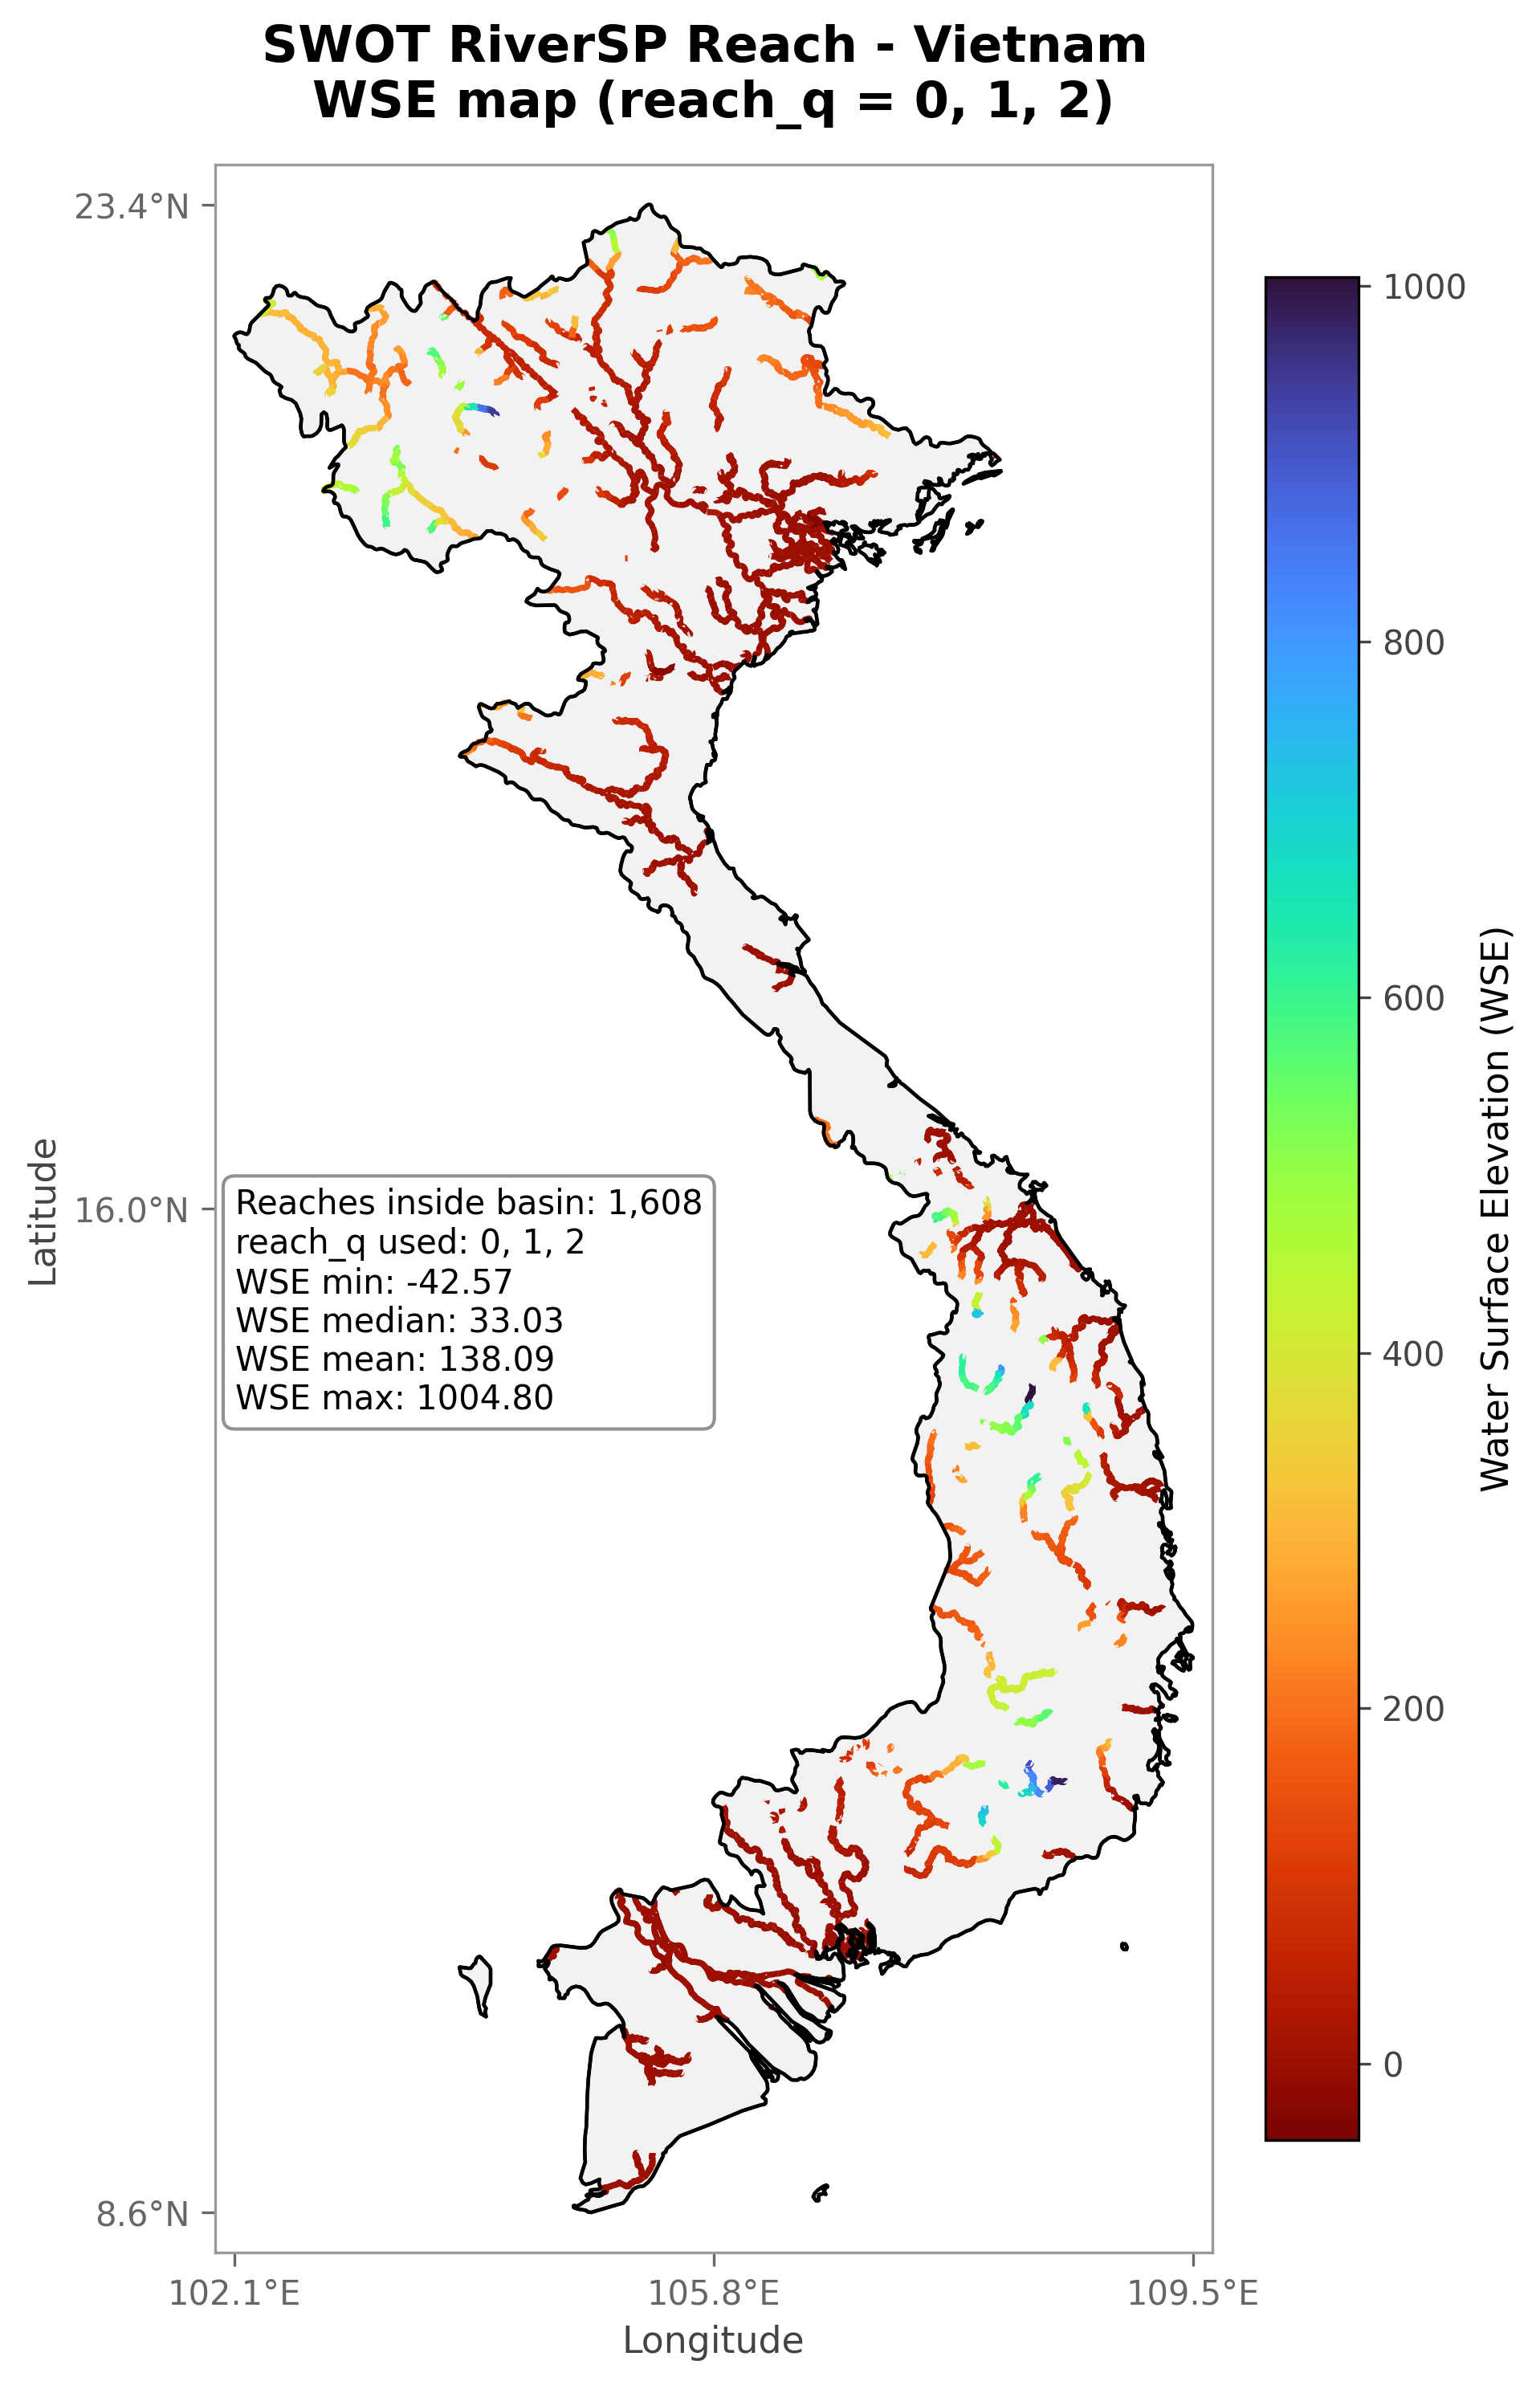

Map saved to: /home/moreira/swot_course/vietnam_river/vietnam_swot_reach_wse_map_q012.png


In [8]:
from pathlib import Path
import zipfile
import tempfile
import shutil

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter


# ============================================================
# USER CONFIGURATION
# ============================================================

COURSE_DIR = Path.home() / "course/swot_data"

# Directory containing the Congo RiverSP Reach ZIP files.
INPUT_DIR = COURSE_DIR / "vietnam_river"

# Example pattern selecting RiverSP Reach files.
ZIP_PATTERN = "SWOT_L2_HR_RiverSP_Reach_050_*.zip"

# Vietnam country boundary.
BASIN_SHP = Path.home() / "course/data/vietnam.gpkg"

# Output files.
OUTPUT_PNG = Path.home() / "outputs_swot_course/vietnam_swot_reach_wse_map_q012.png"

OUTPUT_GPKG = Path.home() / "outputs_swot_course/vietnam_swot_reach_wse_q012.gpkg"



# SWOT reach quality classes retained in this example.
VALID_REACH_Q = [0, 1, 2]

# Candidate column names allow the script to tolerate
# small differences in attribute capitalization.
WSE_CANDIDATES = [
    "wse",
    "WSE"
]

REACH_Q_CANDIDATES = [
    "reach_q",
    "REACH_Q"
]

# Continuous colormap used for Water Surface Elevation.
CMAP_NAME = "turbo_r"


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_first_existing_column(
    gdf,
    candidates,
    label
):
    """
    Return the first candidate column found in a GeoDataFrame.
    """

    for column in candidates:

        if column in gdf.columns:
            return column

    raise ValueError(
        f"Could not find the {label} column. "
        f"Available columns: {list(gdf.columns)}"
    )


def choose_reach_shp(
    zip_path
):
    """
    Identify the Reach shapefile stored inside a RiverSP ZIP file.
    """

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:

        shp_files = [
            name
            for name in z.namelist()
            if name.lower().endswith(".shp")
        ]

    if not shp_files:
        return None

    preferred = [
        shp
        for shp in shp_files
        if "reach" in Path(shp).name.lower()
    ]

    if preferred:
        return preferred[0]

    return shp_files[0]


def extract_shapefile_family(
    zip_path,
    shp_member,
    out_dir
):
    """
    Extract the selected shapefile and all associated files
    (.dbf, .shx, .prj, etc.) from the ZIP archive.
    """

    shp_member = str(
        shp_member
    )

    stem = str(
        Path(shp_member).with_suffix("")
    )

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:

        family = [
            name
            for name in z.namelist()
            if str(
                Path(name).with_suffix("")
            ) == stem
        ]

        for member in family:
            z.extract(
                member,
                path=out_dir
            )

    return (
        Path(out_dir)
        / shp_member
    )


def load_reach_from_zip(
    zip_path
):
    """
    Read the RiverSP Reach shapefile from one ZIP archive.
    """

    shp_member = choose_reach_shp(
        zip_path
    )

    if shp_member is None:

        print(
            f"[WARNING] No shapefile found in: {zip_path.name}"
        )

        return None


    tmp_dir = tempfile.mkdtemp(
        prefix="swot_reach_"
    )

    try:

        shp_path = extract_shapefile_family(
            zip_path,
            shp_member,
            tmp_dir
        )

        gdf = gpd.read_file(
            shp_path
        )

        if gdf.empty:

            print(
                f"[WARNING] Empty shapefile in: {zip_path.name}"
            )

            return None


        # Keep the source filename for traceability.
        gdf["source_zip"] = zip_path.name

        return gdf


    finally:

        shutil.rmtree(
            tmp_dir,
            ignore_errors=True
        )


def format_lon(
    x,
    pos
):
    """
    Format longitude labels using E/W hemispheres.
    """

    hemisphere = (
        "E"
        if x >= 0
        else "W"
    )

    return (
        f"{abs(x):.1f}°{hemisphere}"
    )


def format_lat(
    y,
    pos
):
    """
    Format latitude labels using N/S hemispheres.
    """

    hemisphere = (
        "N"
        if y >= 0
        else "S"
    )

    return (
        f"{abs(y):.1f}°{hemisphere}"
    )


# ============================================================
# LOAD THE BASIN
# ============================================================

print(
    "Reading Vietnam boundary..."
)

basin = gpd.read_file(
    BASIN_SHP
)

if basin.empty:

    raise ValueError(
        "The shapefile is empty."
    )


# Convert the basin to longitude/latitude.
if basin.crs is None:

    print(
        "[WARNING] Basin CRS is undefined. "
        "Assuming EPSG:4326."
    )

    basin = basin.set_crs(
        epsg=4326
    )

else:

    basin = basin.to_crs(
        epsg=4326
    )


# ============================================================
# READ ALL MATCHING RIVERSP ZIP FILES
# ============================================================

zip_files = sorted(
    INPUT_DIR.glob(
        ZIP_PATTERN
    )
)

if not zip_files:

    raise FileNotFoundError(
        f"No files matched the pattern: {ZIP_PATTERN}\n"
        f"Search directory: {INPUT_DIR}"
    )


print(
    f"ZIP files found: {len(zip_files)}"
)


gdfs = []


for i, zip_path in enumerate(
    zip_files,
    start=1
):

    print(
        f"[{i}/{len(zip_files)}] Reading: {zip_path.name}"
    )

    gdf = load_reach_from_zip(
        zip_path
    )

    if (
        gdf is not None
        and not gdf.empty
    ):

        gdfs.append(
            gdf
        )


if not gdfs:

    raise ValueError(
        "No valid RiverSP Reach shapefiles were read."
    )


# Combine all acquisitions into one GeoDataFrame.
reaches = pd.concat(
    gdfs,
    ignore_index=True
)

reaches = gpd.GeoDataFrame(
    reaches,
    geometry="geometry",
    crs=gdfs[0].crs
)


if reaches.crs is None:

    print(
        "[WARNING] Reach CRS is undefined. "
        "Assuming EPSG:4326."
    )

    reaches = reaches.set_crs(
        epsg=4326
    )

else:

    reaches = reaches.to_crs(
        epsg=4326
    )


print(
    f"Total reach geometries read: {len(reaches)}"
)


# ============================================================
# IDENTIFY COLUMNS AND FILTER REACH QUALITY
# ============================================================

wse_col = find_first_existing_column(
    reaches,
    WSE_CANDIDATES,
    "WSE"
)

reach_q_col = find_first_existing_column(
    reaches,
    REACH_Q_CANDIDATES,
    "reach_q"
)


print(
    f"WSE column: {wse_col}"
)

print(
    f"reach_q column: {reach_q_col}"
)


reaches[wse_col] = pd.to_numeric(
    reaches[wse_col],
    errors="coerce"
)

reaches[reach_q_col] = pd.to_numeric(
    reaches[reach_q_col],
    errors="coerce"
)


reaches = reaches.dropna(
    subset=[
        wse_col,
        reach_q_col,
        "geometry"
    ]
).copy()


reaches_f = reaches[
    reaches[reach_q_col]
    .isin(VALID_REACH_Q)
].copy()


if reaches_f.empty:

    raise ValueError(
        "No reaches remained after applying the reach_q filter."
    )


print(
    f"Reaches after reach_q filter: {len(reaches_f)}"
)


# ============================================================
# CLIP REACHES TO THE BASIN
# ============================================================

print(
    "Clipping RiverSP reaches to the Vietnam..."
)


reaches_clip = gpd.clip(
    reaches_f,
    basin
)


# Remove empty geometries created by the clip operation.
reaches_clip = reaches_clip[
    ~reaches_clip.geometry.is_empty
].copy()

reaches_clip = reaches_clip.dropna(
    subset=["geometry"]
)


if reaches_clip.empty:

    raise ValueError(
        "No reach geometries remained after clipping to the vietnam."
    )


print(
    f"Reaches inside basin: {len(reaches_clip)}"
)


# Save the clipped reaches for later analysis.
reaches_clip.to_file(
    OUTPUT_GPKG,
    driver="GPKG"
)

print(
    f"GeoPackage saved to: {OUTPUT_GPKG}"
)


# ============================================================
# CREATE THE BASIN-SCALE WSE MAP
# ============================================================

# Use only the basin extent to define the map view.
minx, miny, maxx, maxy = basin.total_bounds

# Add a small margin around the basin.
dx = (
    (maxx - minx)
    * 0.02
)

dy = (
    (maxy - miny)
    * 0.02
)


minx_plot = minx - dx
maxx_plot = maxx + dx

miny_plot = miny - dy
maxy_plot = maxy + dy


# The color scale is calculated only from reaches
# located inside the basin.
vmin = reaches_clip[
    wse_col
].min()

vmax = reaches_clip[
    wse_col
].max()

norm = Normalize(
    vmin=vmin,
    vmax=vmax
)


fig, ax = plt.subplots(
    figsize=(12, 10),
    dpi=300
)

fig.patch.set_facecolor(
    "white"
)

ax.set_facecolor(
    "white"
)


# ------------------------------------------------------------
# BASIN POLYGON
# ------------------------------------------------------------

basin.plot(
    ax=ax,
    facecolor="#f2f2f2",
    edgecolor="black",
    linewidth=1.0,
    zorder=1
)


# ------------------------------------------------------------
# SWOT RIVER REACHES
# ------------------------------------------------------------

reaches_clip.plot(
    ax=ax,
    column=wse_col,
    cmap=CMAP_NAME,
    linewidth=1.8,
    legend=False,
    zorder=3
)


# Draw the basin boundary above the river reaches.
basin.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.1,
    zorder=4
)


# ============================================================
# MAP EXTENT AND AXES
# ============================================================

ax.set_xlim(
    minx_plot,
    maxx_plot
)

ax.set_ylim(
    miny_plot,
    maxy_plot
)


# Use only three geographic ticks on each axis
# to keep the figure visually clean.
xticks = np.linspace(
    minx,
    maxx,
    3
)

yticks = np.linspace(
    miny,
    maxy,
    3
)


ax.set_xticks(
    xticks
)

ax.set_yticks(
    yticks
)


ax.xaxis.set_major_formatter(
    FuncFormatter(
        format_lon
    )
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        format_lat
    )
)


ax.grid(
    False
)


ax.tick_params(
    axis="both",
    which="major",
    labelsize=10,
    colors="#666666",
    length=4,
    width=0.8
)


for spine in ax.spines.values():

    spine.set_color(
        "#999999"
    )

    spine.set_linewidth(
        0.8
    )


ax.set_title(
    "SWOT RiverSP Reach - Vietnam \n"
    "WSE map (reach_q = 0, 1, 2)",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Longitude",
    fontsize=11,
    color="#444444"
)

ax.set_ylabel(
    "Latitude",
    fontsize=11,
    color="#444444"
)


# ============================================================
# COLORBAR
# ============================================================

sm = ScalarMappable(
    norm=norm,
    cmap=CMAP_NAME
)

sm.set_array([])


cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.02
)

cbar.set_label(
    "Water Surface Elevation (WSE)",
    fontsize=11
)

cbar.ax.tick_params(
    labelsize=10,
    colors="#444444"
)


# ============================================================
# SUMMARY STATISTICS
# ============================================================

stats_text = (
    f"Reaches inside basin: {len(reaches_clip):,}\n"
    f"reach_q used: 0, 1, 2\n"
    f"WSE min: {reaches_clip[wse_col].min():.2f}\n"
    f"WSE median: {reaches_clip[wse_col].median():.2f}\n"
    f"WSE mean: {reaches_clip[wse_col].mean():.2f}\n"
    f"WSE max: {reaches_clip[wse_col].max():.2f}"
)


ax.text(
    0.02,
    0.4,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="bottom",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#888888",
        "alpha": 0.92
    },
    zorder=10
)


# ============================================================
# SAVE AND DISPLAY
# ============================================================

plt.tight_layout()

plt.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"Map saved to: {OUTPUT_PNG}"
)
